In [1]:
try:
    %load_ext autotime
except:
    %pip3 install ipython-autotime
    %load_ext autotime

time: 0 ns (started: 2024-11-16 17:42:28 -08:00)


We will study a famous 1.5-factor approximation for metric TSPs due to Nicos Christofides who published it in 1976 and independently by Anatoli Serdyukov (though the  <a href="http://nas1.math.nsc.ru/aim/journals/us/us17/us17_007.pdf">article is in Russian</a>).

Christofides, Nicos (1976), <a href="https://apps.dtic.mil/dtic/tr/fulltext/u2/a025602.pdf">Worst-case analysis of a new heuristic for the travelling salesman problem</a> , Report 388, Graduate School of Industrial Administration, CMU.

This remained the best known approximation for metric TSPs until Karlin, Klein and Gharan showed an improved approximation ratio of  1.5−10<sup>−34</sup>, what they call a "slight improvement". However, new algorithmic techniques often ride on such improvements and are very valuable even if they do not "move the needle" by all that much.

Anna Karlin, Nathan Klein and Shayan Gharan (2021), A (slightly) <a href="https://dl.acm.org/doi/10.1145/3406325.3451009">improved approximation algorithm</a> for metric TSP, Proceedings of the 53rd Annual ACM SIGACT Symposium on Theory of Computing (STOC), ACM Press, pp. 32–45, 2021.

The basic idea here involves the following four high level steps:

- We will find a suitable subgraph of the original graph G over which the TSP is defined.
- We will traverse the subgraph in some manner visiting all its nodes and edges in a systematic manner.
- We will use a trick called short-cutting to turn our traversal of the subgraph from the previous step into a TSP tour.
- By choosing the subgraph carefully and relying on the metric TSP properties, we will prove that our TSP tour is within some  𝛼 factor of the optimal tour.

<h2>Metric TSP</h2>

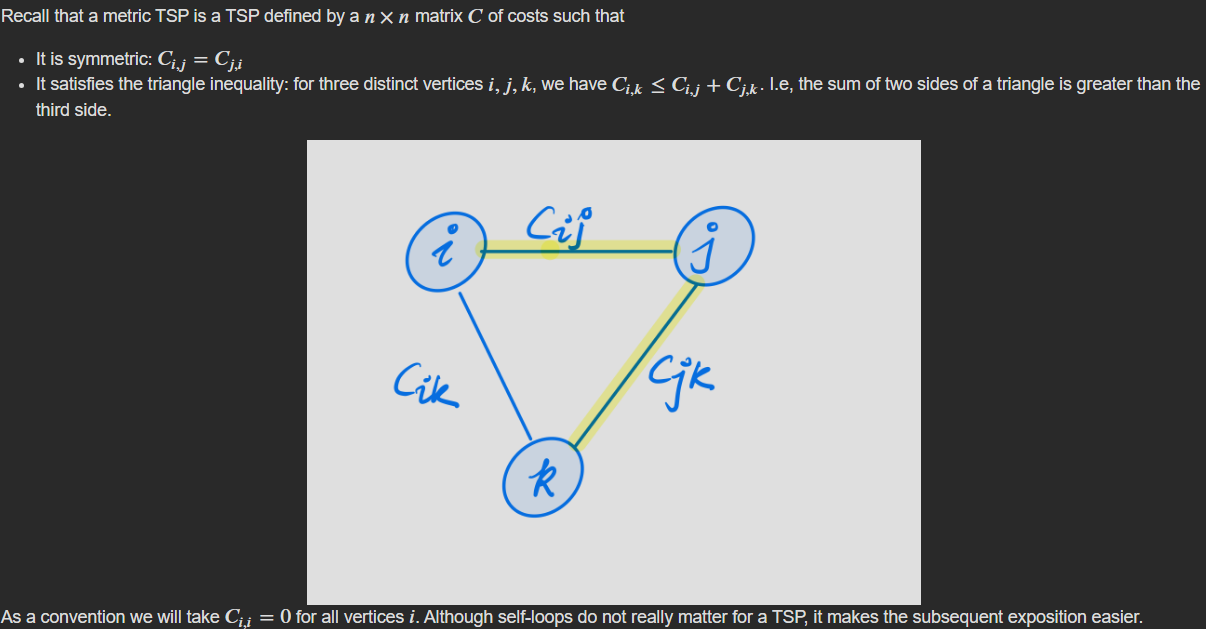
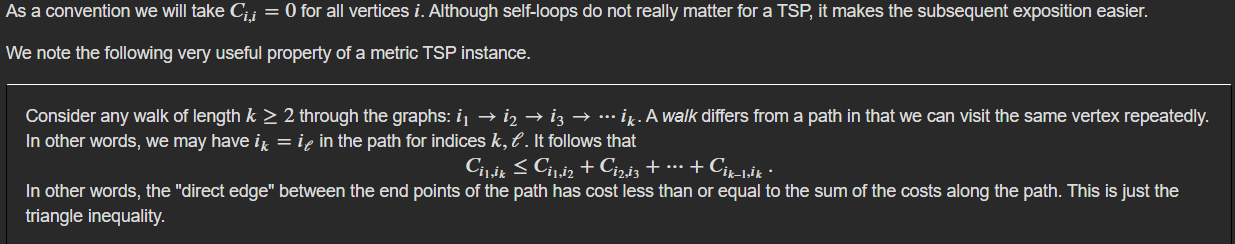


<h2>Minimum Spanning Tree and a 2-Factor Approximation</h2>

We will first show a 2-factor approximation using minimum spanning trees. The concept of a minimum spanning tree was covered in a previous of this sequence on "Trees and Graphs".

A spanning tree of a weighted undirected graph  𝐺
  is a subgraph of  𝐺  that is a tree (is strongly connected and acyclic). A minimum spanning tree (MST) is one whose sum of edge weights is the smallest amonst all spanning trees.
  
Back in our previous course, we talked about the properties of minimum spanning trees and introduced a very efficient algorithm called Kruskal's algorithm that runs in time  𝑂(|𝐸|log(|𝐸|))
  where  |𝐸| is the number of edges of the graph. Here is an illuatration of the MST for some example TSPs.

In [2]:
import networkx as nx
from matplotlib import pyplot as plt

def compute_mst_and_draw(cost_matrix):
    n = len(cost_matrix)
    G = nx.Graph()
    for i in range(n):
        for j in range(i):
            G.add_edge(i, j, weight=cost_matrix[i][j])
    T = nx.minimum_spanning_tree(G, algorithm='kruskal') # networkx has a very convenient implementation of MST for undirected weighted graphs
    pos=nx.circular_layout(G)
    nx.draw(G, pos, with_labels=True, style='--')
    labels = nx.get_edge_attributes(G,'weight')
    nx.draw_networkx_edges(T, pos, edge_color="red", style='-', width=2)
    nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

time: 9.49 s (started: 2024-11-16 18:08:55 -08:00)


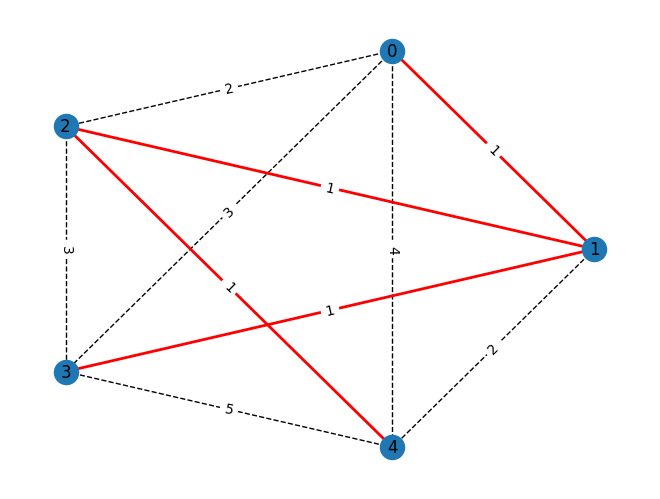

time: 141 ms (started: 2024-11-16 18:15:29 -08:00)


In [5]:
# Example 1
cost_matrix=[
    [0, 1, 2, 3, 4],
    [1, 0, 1, 1, 2],
    [2, 1, 0, 3, 1],
    [3, 1, 3, 4, 5],
    [4, 2, 1, 5, 0]
]
compute_mst_and_draw(cost_matrix)

# We have drawn a TSP instance with all the edges and edge weights shown. 
# The edges in the minimum spanning tree are shown in bold red whereas the non-MST edges 
# are shown as dashed lines. Notice that the subgraph defined by the MST is indeed an acyclic 
# graph, it connects every node in the original graph. It is not easy to see directly but it has the smallest 
# weights amongst all such spanning trees.

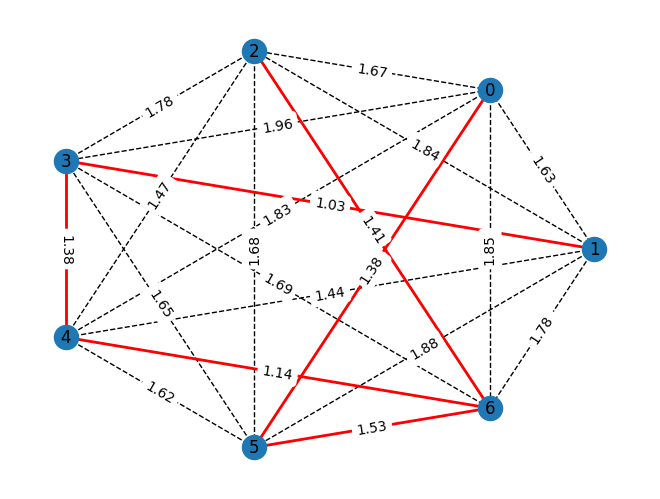

time: 203 ms (started: 2024-11-16 18:22:23 -08:00)


In [6]:
# Example 2 - We demonstrate on a TSP instance with 7 nodes.
from random import uniform
cost_matrix = [[0 for i in range(7)] for j in range(7)] # create a matrix of dimensions 8 x 8
for i in range(7):
    for j in range(i):
        cost_matrix[i][j] = (int(uniform(1, 2)*100)/100)
        cost_matrix[j][i] = cost_matrix[i][j]
compute_mst_and_draw(cost_matrix)

<h2>Building a TSP Tour from a MST with Shortcutting.</h2>

The idea is very simple:

- Compute a MST for our input graph  𝐺
- Start from a fixed starting vertex of the minimum spanning tree  𝑇 obtained and perform a depth-first traversal of the MST  𝑇.
- Whenever the DFS visits a vertex  𝑣 for the first time add it to the tour.

Here is an illustration of this DFS on a MST taken from Example 1 above.

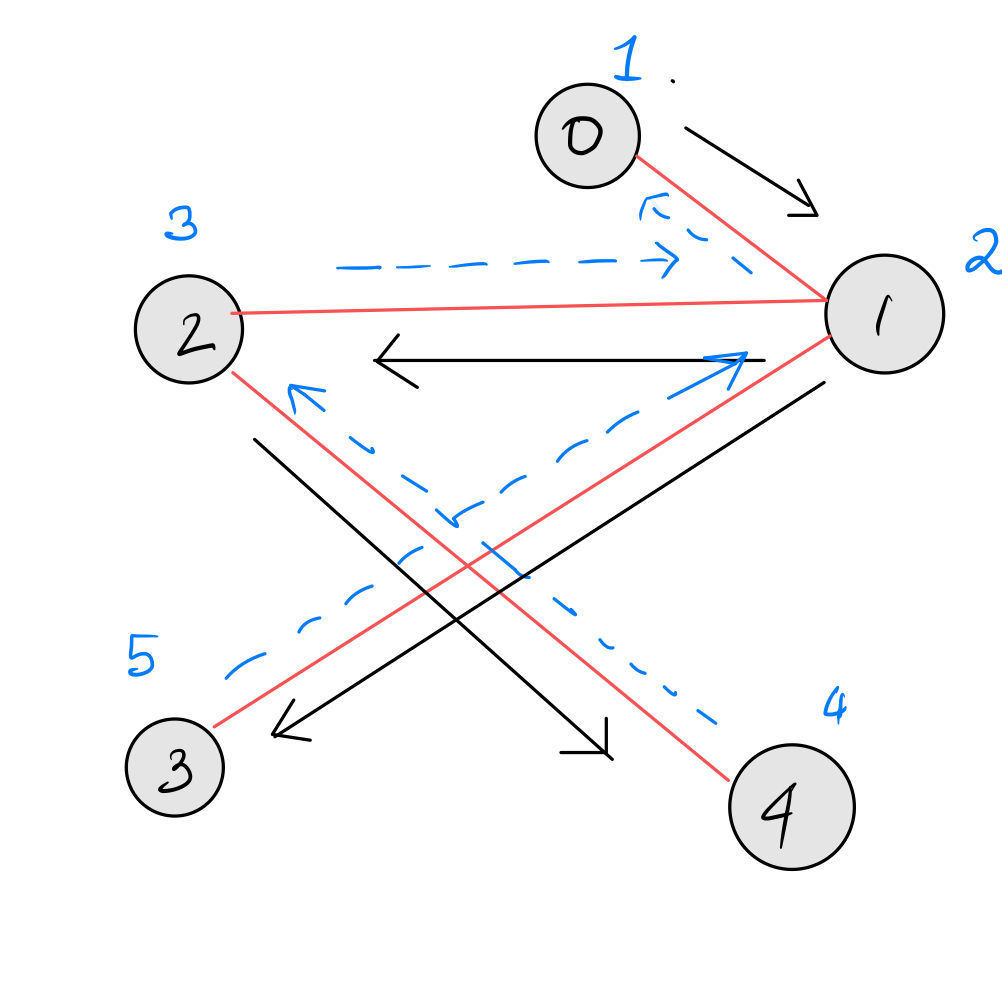

The red edges are those present in the MST. The DFS works as follows:

visit 0
visit 1
visit 2
visit 4
Backtrack to 2, 1 (shown in dashed blue)
visit 3
Backtrack to 1, 0

The TSP tour is constructed by taking the order in which the DFS visits nodes:



There are two edges shown in red squiggly arrows:  
4⇝3 and  3⇝0.


The reason is that these are formed by "shortcutting". In other words, the DFS itself goes from nodes 4 to 3 as follows:4⇝2⇝1→3


the blue squiggly arrows denote that DFS is backtracking. However, the visits to  2,1
  do not count as part of the TSP tour. Instead, the TSP tour we construct directly goes from vertex  4 straight to the new vertex  3. This is the essence of "shortcutting": whenver our traversal tries to repeat a vertex we wait until it visits a new previously unseen vertex and add that vertex to the tour.

Here is the code to carry out the construction so far.



In [7]:
import networkx as nx
def tsp_tour_from_mst(cost_matrix, debug=True):
    n = len(cost_matrix)
    assert all(len(cj) == n for cj in cost_matrix), f'cost matrix is not {n}x{n}'
    G = nx.Graph()
    for i in range(n):
        for j in range(i):
            G.add_edge(i, j, weight = cost_matrix[i][j])
    T = nx.minimum_spanning_tree(G, algorithm='kruskal')
    dfs_traversal = nx.dfs_edges(T, source=0) # do a dfs traversal starting from source vertex 0
    l = list(dfs_traversal)
    if debug:
        print('DFS traversal of MST: ')
        print(l)
    tsp_tour = [0] # initialize the tour
    tour_cost = 0
    for (i, j) in l: # go through the edges in the DFS traversal in order
        assert i in tsp_tour # we will have seen the node `i' already in the tour
        if j not in tsp_tour: # have I seen the node j before?
            if debug:
                if i != tsp_tour[-1]: 
                    print(f'\t Shortcutting edge: {(tsp_tour[-1], j)} ')
                else:
                    print(f'\t Tree edge: {(i,j)}')
            tour_cost += cost_matrix[tsp_tour[-1]][j] # add to the cost
            tsp_tour.append(j)# append it to the tour
    if debug:
        print(f'\t Shortcutting edge {(tsp_tour[-1],0)}') 
    tour_cost += cost_matrix[tsp_tour[-1]][0]
    print(f'TSP Tour: {tsp_tour}')
    print(f'Tour Cost: {tour_cost}')
    return (tsp_tour, tour_cost)
        

time: 0 ns (started: 2024-11-16 18:30:54 -08:00)


DFS traversal of MST: 
[(0, 1), (1, 2), (2, 4), (1, 3)]
	 Tree edge: (0, 1)
	 Tree edge: (1, 2)
	 Tree edge: (2, 4)
	 Shortcutting edge: (4, 3) 
	 Shortcutting edge (3, 0)
TSP Tour: [0, 1, 2, 4, 3]
Tour Cost: 11


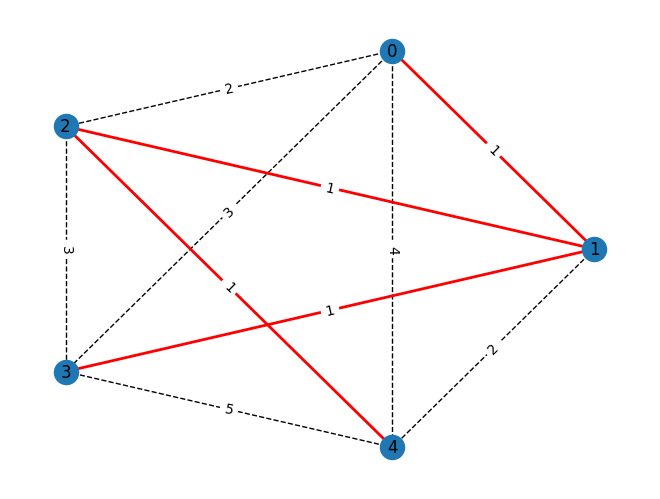

time: 141 ms (started: 2024-11-16 18:32:10 -08:00)


In [8]:
cost_matrix=[
    [0, 1, 2, 3, 4],
    [1, 0, 1, 1, 2],
    [2, 1, 0, 3, 1],
    [3, 1, 3, 4, 5],
    [4, 2, 1, 5, 0]
]
compute_mst_and_draw(cost_matrix)
(tsp_tour, tour_cost) = tsp_tour_from_mst(cost_matrix)

DFS traversal of MST: 
[(0, 3), (3, 2), (3, 4), (4, 1), (3, 5), (0, 6)]
	 Tree edge: (0, 3)
	 Tree edge: (3, 2)
	 Shortcutting edge: (2, 4) 
	 Tree edge: (4, 1)
	 Shortcutting edge: (1, 5) 
	 Shortcutting edge: (5, 6) 
	 Shortcutting edge (6, 0)
TSP Tour: [0, 3, 2, 4, 1, 5, 6]
Tour Cost: 8.95


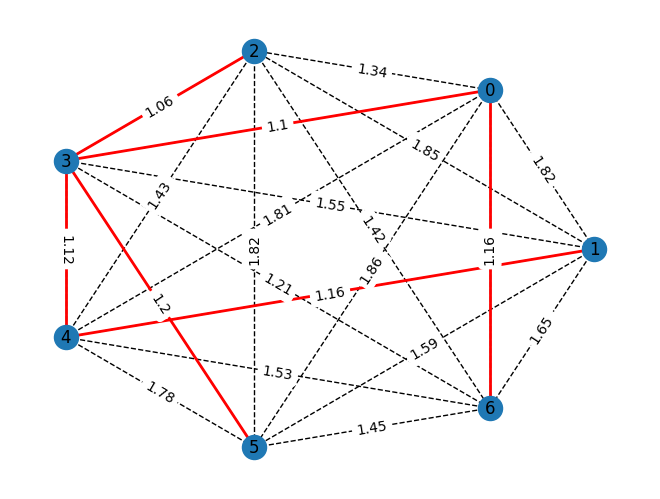

time: 203 ms (started: 2024-11-16 18:32:30 -08:00)


In [9]:
from random import uniform
cost_matrix = [[0 for i in range(7)] for j in range(7)] # create a matrix of dimensions 8 x 8
for i in range(7):
    for j in range(i):
        cost_matrix[i][j] = (int(uniform(1, 2)*100)/100)
        cost_matrix[j][i] = cost_matrix[i][j]
compute_mst_and_draw(cost_matrix)
(tsp_tour, tour_cost) = tsp_tour_from_mst(cost_matrix)

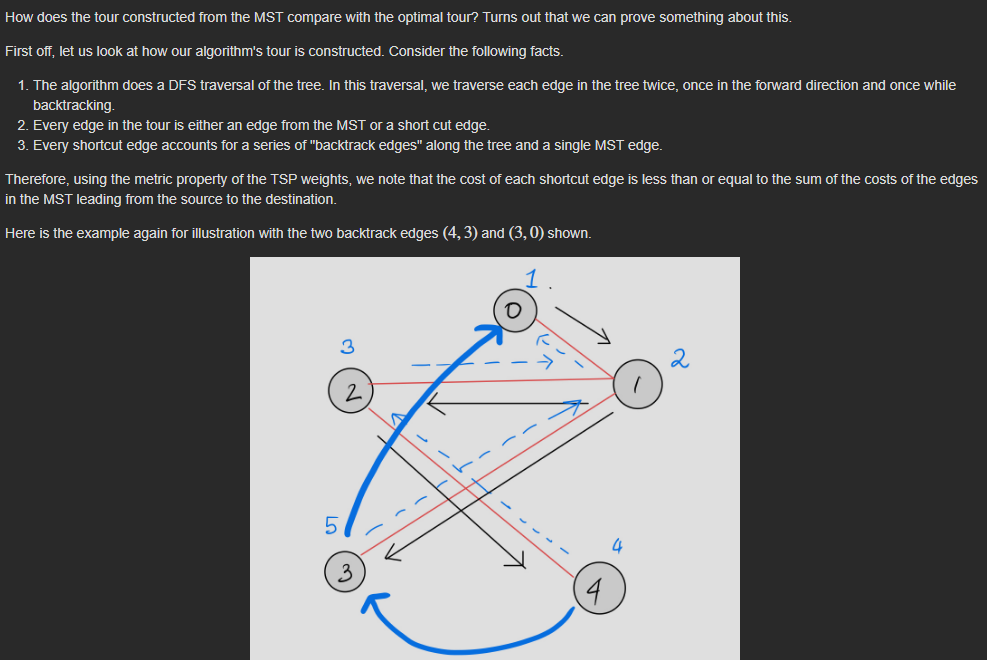
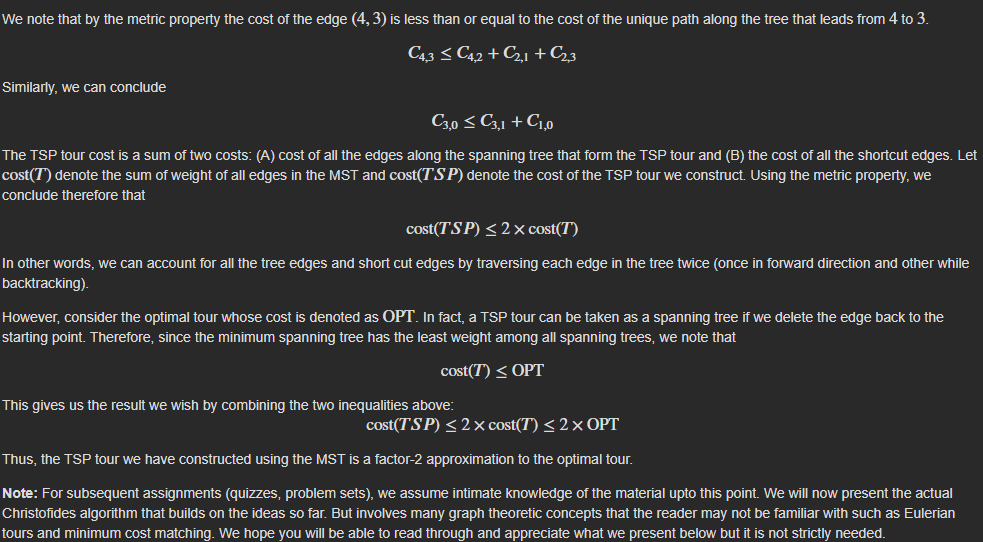

<h2>Improving the approximation</h2>

We can improve the approximation by improving how we traverse the MST. The idea is as follows: if we just traverse the MST in a depth-first manner, we are forced to add shortcut edges and this costs twice as much as the cost of the MST.

We need to avoid doing a DFS of the MST in the first place. What if we can cleverly add extra edges to the MST up front in a way that these edges are low cost and enable us to traverse the MST in a different way?

Eulerian Tours
The key is that instead of doing a depth-first traversal of the MST, we will do an Eulerian tour. What is an Eulerian tour?

An Eulerian tour of the graph is a traversal that visits every edge exactly once and returns to where we started.
An Eulerian tour is different from a TSP tour. Whereas a TSP tour insists on visiting every vertex exactly once, an Eulerian tour visits every edge once. It can visit vertices multiple times if needed.

Here are some examples of Eulerian tours.

In [10]:
import networkx as nx
from matplotlib import pyplot as plt 

def construct_eulerian_tour(list_of_edges):
    G = nx.Graph()
    G.add_edges_from(list_of_edges)
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightgray')
    plt.show()
    e = nx.eulerian_circuit(G)
    print('Found Eulerian Tour: ')
    first=True
    for (i,j) in e:
        if not first:
            print('->', end='')
        first=False
        print(f' {(i,j)} ', end='')
        

time: 0 ns (started: 2024-11-16 18:48:34 -08:00)


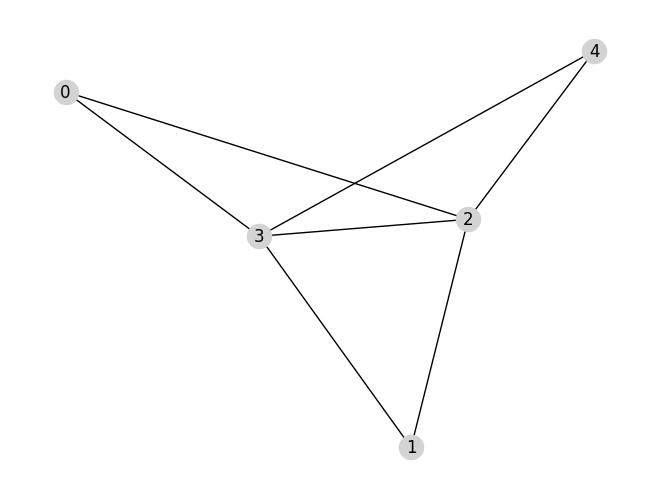

Found Eulerian Tour: 
 (0, 3) -> (3, 4) -> (4, 2) -> (2, 3) -> (3, 1) -> (1, 2) -> (2, 0) time: 672 ms (started: 2024-11-16 18:48:43 -08:00)


In [11]:
construct_eulerian_tour([(0,2), (0,3), (1,2), (1,3), (2,3),(2,4),(3,4)])

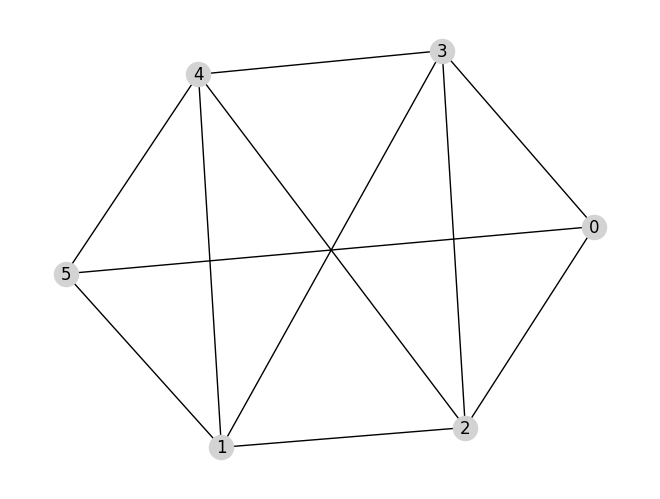

Found Eulerian Tour: 


NetworkXError: G is not Eulerian.

time: 625 ms (started: 2024-11-16 19:06:28 -08:00)


In [12]:
construct_eulerian_tour([(0,2), (0,3), (1,2), (1,3), (2,3),(2,4),(3,4), (4,5), (4,1), (5,1), (5,0)])

<h2>Matching and Minimum Weight Matching</h2>

Another useful concept is that of a matching in a graph. Given a graph  𝐺  , a matching in a graph is subset of edges  𝑀  <u> such that no two edges from  𝑀 share a vertex </u>. Let us visualize what a matching looks like with a picture:

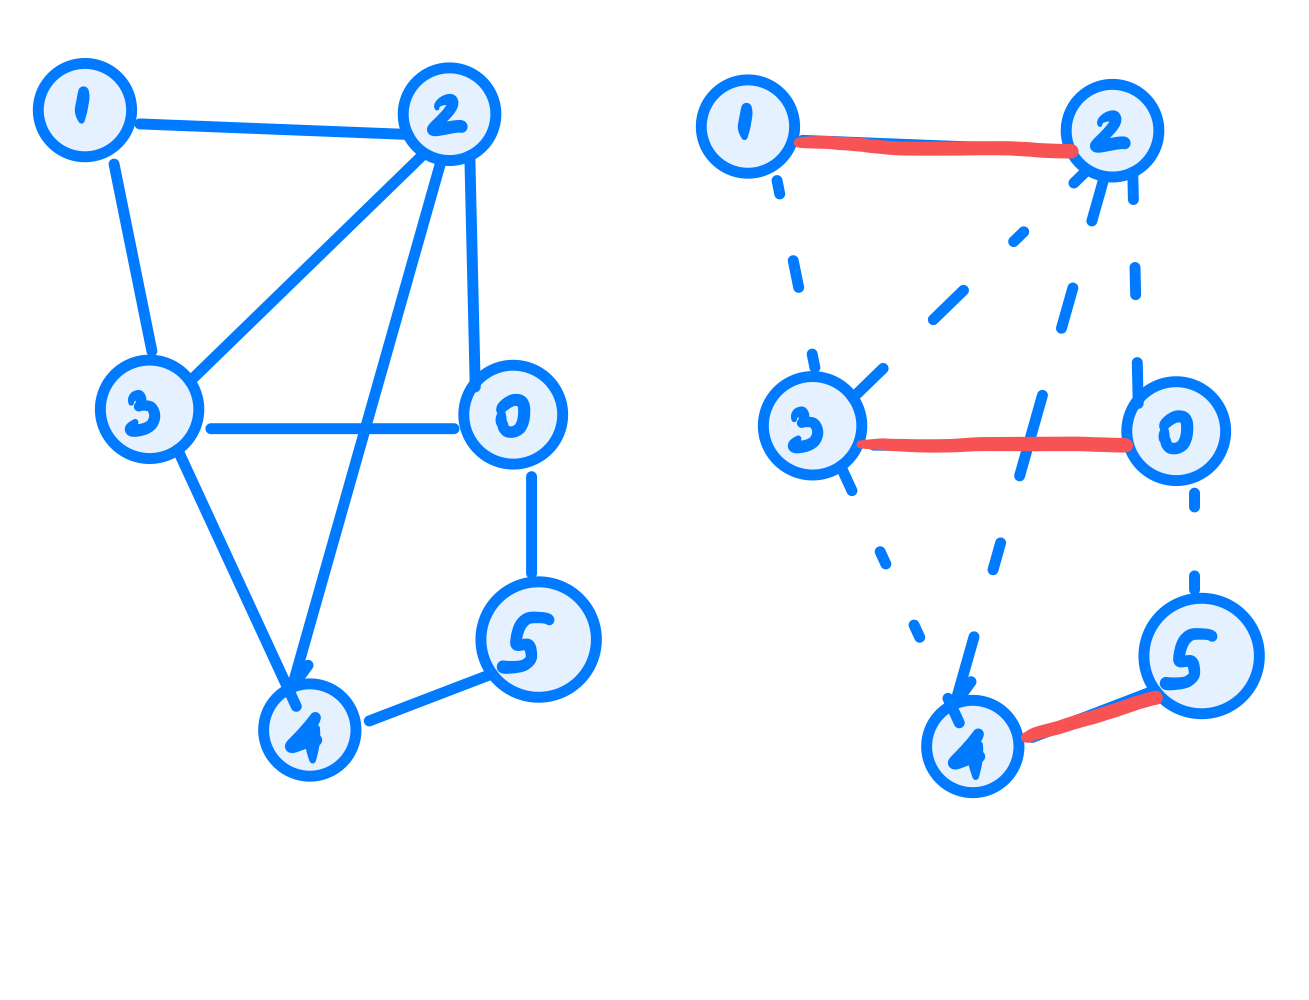

To the left, we have shown a graph and to the right, we show a matching consisting of the edges shown in red. Note that a matching identifies pairs of vertices connected by an edge in the graph so that no two pairs share a common vertex.

Given a complete graph with even number of nodes, there is an <u> efficient algorithm by Edmonds </u> that can compute a minimum weight matching  𝑀   such that the sum of edge weights of  𝑀   is minimized over all possible matchings.

<h2>Eulerian Tours of the MST</h2>

The problem with the MST is that it is a tree and therefore there are going to be nodes with an odd number of edges on it. You can check the MSTs for the two examples above to note that there are going to be at least two nodes (often more) with odd number of edges.

Going back to Example 1 above note that nodes 0, 1, 3, 4 all have odd degrees in the MST.

However, we note that the number of such nodes with odd degrees must always be even (there is a very simple proof for this but we will not digress).

The whole idea is as follows:

- Construct the MST of the original graph  𝐺.
- Identify all the odd degree vertices of the MST. There will be an even number of them.
    - Let  𝑂 be all the vertices of odd degree.
    - Construct the subgraph of  𝐺 involving only the vertices in  𝑂.
    - Compute a minimal cost matching of the subgraph induced by vertices  𝑂. Let  𝑀
        be the set of edges in the matching.
- Add the minimal cost matching edges  𝑀 to the MST edges  𝑇. This graph is guaranteed to have an even degree for every node.
    - Note that  𝑀 and  𝑇 can have edges in common. Therefore combining the edges results in a multi-graph where two nodes can have more than one edges between them.
- Compute an Eulerian tour of the graph given by the matching and MST edges.
    - Algorithms for constructing Eulerian tours work on multigraphs as well.
- Shortcut the Eulerian tour to produce a TSP tour.

In [13]:
import networkx as nx

def christofides_tsp_construction(cost_matrix, debug=True):
    #1. Construct a MST
    n = len(cost_matrix)
    assert all(len(cj) == n for cj in cost_matrix), f'cost matrix is not {n}x{n}'
    G = nx.Graph()
    for i in range(n):
        for j in range(i):
            G.add_edge(i, j, weight = cost_matrix[i][j])
    # use networkx to construct MST
    T = nx.minimum_spanning_tree(G, algorithm='kruskal')
    if debug:
        pos=nx.circular_layout(G)
        plt.figure()
        nx.draw(G, pos, with_labels=True, style='--')
        labels = nx.get_edge_attributes(G,'weight')
        nx.draw_networkx_edges(T, pos, edge_color="red", style='-', width=2)
        nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
        plt.title('Original Graph with Minimum Spanning Tree Edges (red)')
        plt.show()
    #2. Get all odd degree vertices in the MST
    mst_degrees = {i:0 for i in range(n)} # initialize all node degrees to 0
    for (i,j) in T.edges(): #traverse the MST edges one by one
        mst_degrees[i] += 1
        mst_degrees[j] += 1 # increment the degrees of i, j
    odd_degree_nodes = [] # collect all odd degree MST nodes
    for (i, deg) in mst_degrees.items():
        if deg %2 == 1: # if degree is odd 
            odd_degree_nodes.append(i) # add it to odd degree list
    #3. Construct subgraph with odd degree MST nodes
    if debug:
        print(f'Odd degree MST nodes are: {odd_degree_nodes}')
    O = nx.Graph()
    for i in odd_degree_nodes:
        for j in odd_degree_nodes:
            if i < j:
                O.add_edge(i, j, weight=cost_matrix[i][j])
    #4. Compute a matching
    M = nx.min_weight_matching(O)
    if debug:
        print('Min weight matching edges: {', end='')
        for (i,j) in M:
            print(f' {(i,j)} ', end ='')
        print('}')
        plt.figure()
        pos1=nx.circular_layout(O)
        nx.draw(O, pos1, with_labels=True, style='--')
        nx.draw_networkx_edges(O, pos1, edgelist=list(M), edge_color="blue", style='-', width=2)
        labels = nx.get_edge_attributes(O,'weight')
        nx.draw_networkx_edge_labels(O,pos1,edge_labels=labels)
        plt.title('Odd Degree MST nodes subgraph with Minimum Weight Matching')
        plt.show()
    #5. Construct Eulerian Tour
    TplusM = nx.MultiGraph() # we will now construct a multi graph that will involve edges from MST and TSP
    for (i,j) in T.edges(): #add MST edges
        TplusM.add_edge(i, j, weight=cost_matrix[i][j], source='mst')
    for (i,j) in M:
        TplusM.add_edge(i, j, weight=cost_matrix[i][j], source='matching')
    eulerian_circuit = nx.eulerian_circuit(TplusM, source=0)
    tour = [0]
    tour_cost = 0
    # Shortcut the Eulerian tour exactly the same way we shortcut the DFS in the original version
    for (i, j) in eulerian_circuit:
        if j not in tour: # have we seen j before?
            tour_cost = tour_cost + cost_matrix[tour[-1]][j] # update tour cost.
            tour.append(j) #if not add it to the tour
    tour_cost = tour_cost + cost_matrix[tour[-1]][0]
    print(f'Found TSP Tour: {tour}')
    print(f'Tour cost: {tour_cost}')
    return  tour, tour_cost

time: 16 ms (started: 2024-11-16 19:39:58 -08:00)


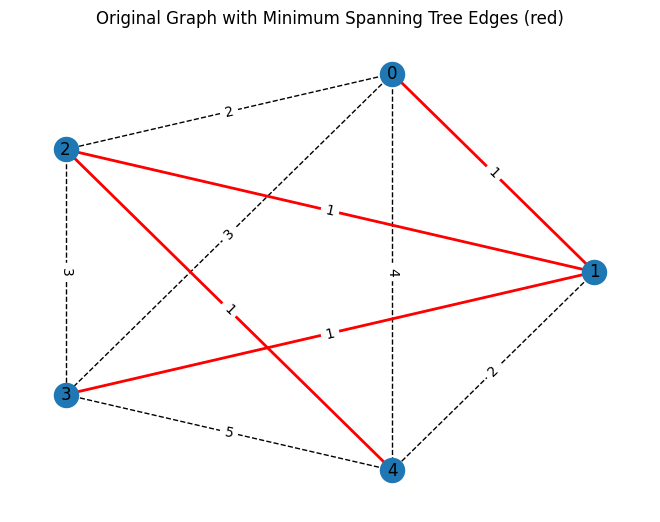

Odd degree MST nodes are: [0, 1, 3, 4]
Min weight matching edges: { (3, 1)  (4, 0) }


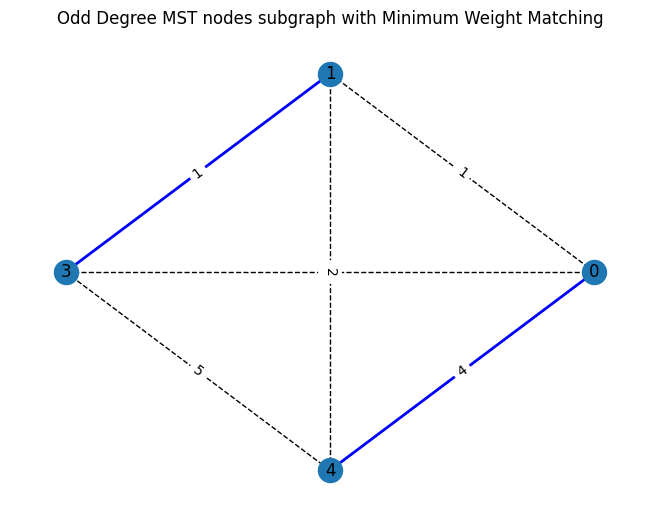

Found TSP Tour: [0, 4, 2, 1, 3]
Tour cost: 10


([0, 4, 2, 1, 3], 10)

time: 281 ms (started: 2024-11-16 19:40:06 -08:00)


In [14]:
cost_matrix=[
    [0, 1, 2, 3, 4],
    [1, 0, 1, 1, 2],
    [2, 1, 0, 3, 1],
    [3, 1, 3, 4, 5],
    [4, 2, 1, 5, 0]
]
christofides_tsp_construction(cost_matrix)

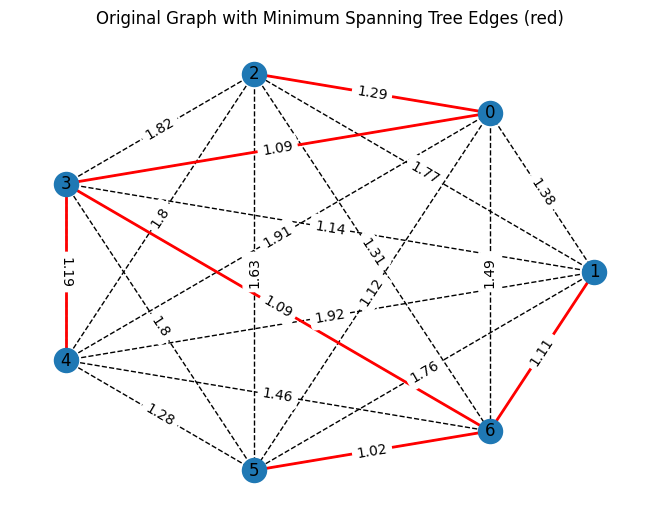

Odd degree MST nodes are: [1, 2, 3, 4, 5, 6]
Min weight matching edges: { (6, 2)  (5, 4)  (1, 3) }


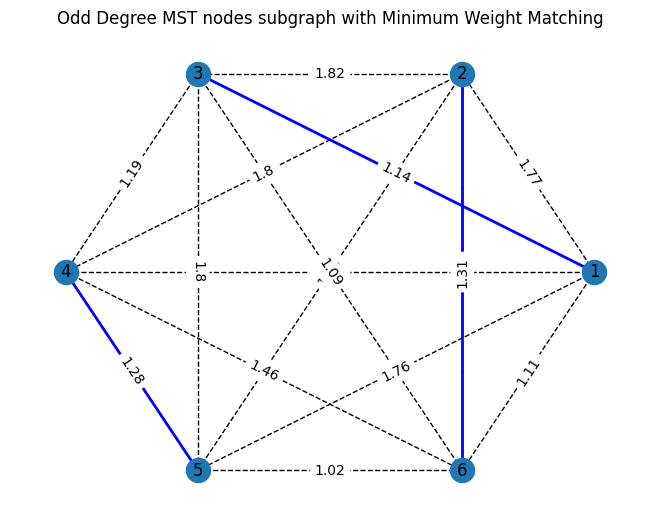

Found TSP Tour: [0, 2, 6, 5, 4, 3, 1]
Tour cost: 8.61
time: 328 ms (started: 2024-11-16 19:41:07 -08:00)


In [16]:
from random import uniform
cost_matrix = [[0 for i in range(7)] for j in range(7)] # create a matrix of dimensions 8 x 8
for i in range(7):
    for j in range(i):
        cost_matrix[i][j] = (int(uniform(1, 2)*100)/100)
        cost_matrix[j][i] = cost_matrix[i][j]
(tsp_tour, tour_cost) = christofides_tsp_construction(cost_matrix)

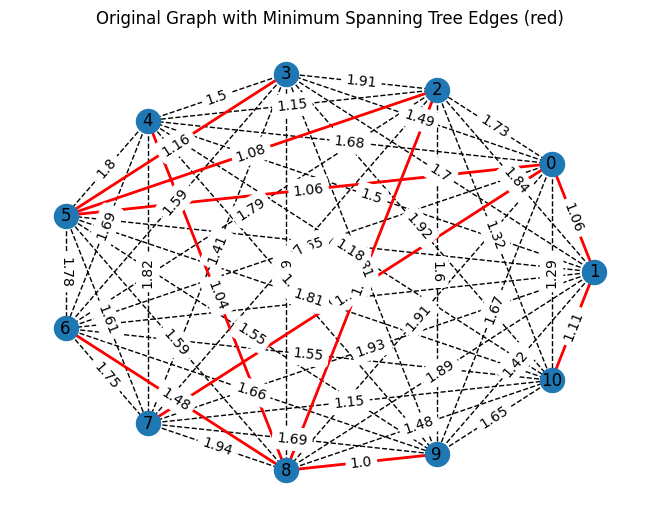

Odd degree MST nodes are: [0, 3, 4, 5, 6, 7, 9, 10]
Min weight matching edges: { (4, 9)  (6, 3)  (5, 0)  (10, 7) }


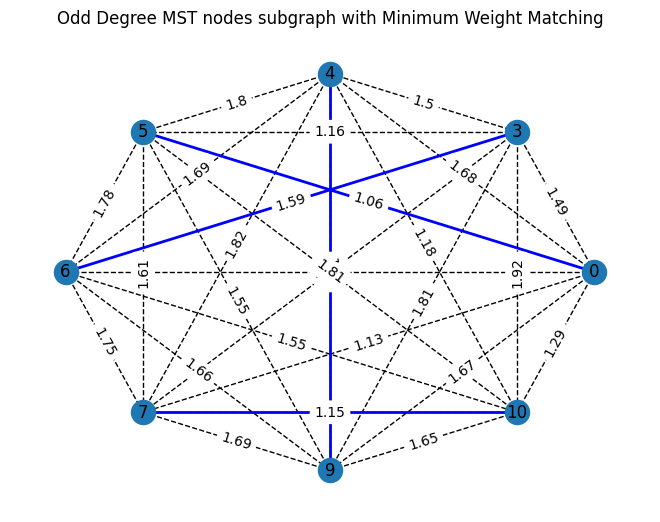

Found TSP Tour: [0, 5, 3, 6, 8, 9, 4, 2, 7, 10, 1]
Tour cost: 13.780000000000001
time: 547 ms (started: 2024-11-16 19:42:08 -08:00)


In [17]:
from random import uniform
n = 11
cost_matrix = [[0 for i in range(n)] for j in range(n)] # create a matrix of dimensions 8 x 8
for i in range(n):
    for j in range(i):
        cost_matrix[i][j] = (int(uniform(1, 2)*100)/100)
        cost_matrix[j][i] = cost_matrix[i][j]
(tsp_tour, tour_cost) = christofides_tsp_construction(cost_matrix)

<h2> Analysis of Christofides Algorithm </h2>

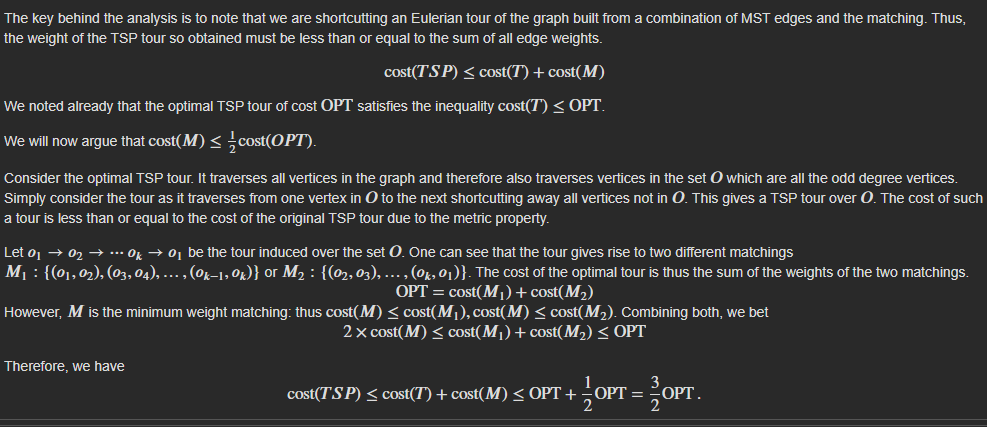

Note- for the TSP tour of only odd incidence vertices - k is even since there are even number of odd incidence vertices. Remove every other step in this tour. You get a matching M1. If you remove the other set of alternate edges you get matching M2. So we are getting 2 pairs of matching cost of each of  which should  be less than minimum weight matching.